<a href="https://colab.research.google.com/github/mycelialmeese/Deep-Learning-Final-Project/blob/main/Chest_Xray_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Intro to Deep Learning Final Project: Chest X-Ray Diagnosis**

## **Background**

The goal of this project is to create a Convolution Neural Net capable of detecting either pneumonia, tuberculosis (TB), or neither from a chest x-ray. Our data comes from [this dataset in Kaggle](https://www.kaggle.com/datasets/muhammadrehan00/chest-xray-dataset).

Both pneumonia and TB are serious medical conditions, with pneumonia being very [prevelant in the USA](https://www.cdc.gov/nchs/fastats/pneumonia.htm) (over 1.2 million cases annually) and TB being [prevelant in many developing countries](https://www.who.int/teams/global-programme-on-tuberculosis-and-lung-health/tb-reports/global-tuberculosis-report-2024/tb-disease-burden/1-1-tb-incidence) (particulary Africa). Pneumonia cases acount for over 40,000 deaths per year in the USA and accounts for over 15% of children's deaths under the age of 5 globally. TB causes over 1 million deaths globally every year.


In [37]:
# Loading dependencies
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from pathlib import Path
import os
from keras import layers
from sklearn.model_selection import train_test_split
import tensorflow as tf
import kagglehub
import kagglehub

## **Exploratory Data Analysis**
First let's load in the image set to look at the number of images in each catergory as well as their dimensions.

In [38]:
path = kagglehub.dataset_download("muhammadrehan00/chest-xray-dataset")
print("Path to data:", path)

Using Colab cache for faster access to the 'chest-xray-dataset' dataset.
Path to data: /kaggle/input/chest-xray-dataset


Using Colab cache for faster access to the 'chest-xray-dataset' dataset.
Path to dataset: /kaggle/input/chest-xray-dataset
Train folder: /kaggle/input/chest-xray-dataset/train/
Test folder: /kaggle/input/chest-xray-dataset/test/
Image Size: (256, 256)


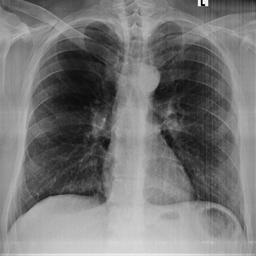

In [39]:

# Download the dataset (this returns the actual path where it's stored)
path = kagglehub.dataset_download("muhammadrehan00/chest-xray-dataset")
print("Path to dataset:", path)

# The path variable now contains the correct location
# Build your folder paths from this base path
train_folder = str(Path(path) / "train") + "/"
test_folder = str(Path(path) / "test") + "/"

print("Train folder:", train_folder)
print("Test folder:", test_folder)

# Now try to open the image
from PIL import Image
img = Image.open(train_folder + "normal/normal-1000.jpg")
h, w = img.size
print("Image Size:", (h, w))
img

In [40]:
# We also need to see what the different image sizes we are dealing with are
def get_image_sizes(folder_loc):
  folder = Path(folder_loc)
  min_h = float('inf')
  max_h = 0
  min_w = float('inf')
  max_w = 0
  for sub_path in folder.iterdir():
    for img_path in sub_path.iterdir():
        img = Image.open(img_path)
        w, h = img.size
        if h < min_h:
          min_h = h
        if h > max_h:
          max_h = h
        if w < min_w:
          min_w = w
        if w > max_w:
          max_w = w

  return (min_h, max_h, min_w, max_w)

(min_h, max_h, min_w, max_w) = get_image_sizes(train_folder)


In [41]:
print("Min Image Height: ", min_h,
      "\nMax Image Height: ", max_h,
      "\nMin Image Width: ",min_w,
      "\nMax Image Width: ",max_w)

Min Image Height:  127 
Max Image Height:  2713 
Min Image Width:  144 
Max Image Width:  2916


Since we are dealing with images of different sizes we will resize the images later to a consistent 256x256 RBG dimension.

Let's now take a look at the number of images per catergory in the testing and training sets. We also need to create dataframes that contain the label for each catergory.

In [42]:
def create_label_df(folder_loc):
    parent_path = Path(folder_loc)
    img_folders = [f for f in parent_path.iterdir() if f.is_dir()]
    img_class = sorted([f.name for f in img_folders])
    print('Categories Found: ', img_class)
    data = []
    for img_folder in img_folders:
        class_name = img_folder.name
        for img_file in img_folder.iterdir():
            if img_file.suffix.lower() == '.jpg':
                data.append({
                    'image_path': str(img_file),
                    'label': class_name
                })
    df = pd.DataFrame(data)
    for class_name in img_class:
        df[class_name] = (df['label'] == class_name).astype(int)
    return df

def add_image_dimensions_to_df(df):
    heights = []
    widths = []

    for img_path in df['image_path']:
        img = Image.open(img_path)
        w, h = img.size
        heights.append(h)
        widths.append(w)

    df['original_height'] = heights
    df['original_width'] = widths
    df['height_ratio'] = df['original_height'] / 256.0
    df['width_ratio'] = df['original_width'] / 256.0

    return df


In [43]:
train_df = create_label_df(train_folder)
train_df = add_image_dimensions_to_df(train_df)


train_df, val_df = train_test_split( train_df,  test_size=0.2, stratify=train_df['label'], random_state=467)
test_df = create_label_df(test_folder)
test_df = add_image_dimensions_to_df(test_df)

print("\nTraining Data: ", "\n\tNormal Images: ",
      len(train_df[train_df['normal'] == 1]),
      "\n\tPneumonia Images: ",
      len(train_df[train_df['pneumonia'] == 1]),
      "\n\tTuberculosis Images: ",
      len(train_df[train_df['tuberculosis'] == 1]),

      "\nValidation Data: ", "\n\tNormal Images: ",
      len(val_df[val_df['normal'] == 1]),
      "\n\tPneumonia Images: ",
      len(val_df[val_df['pneumonia'] == 1]),
      "\n\tTuberculosis Images: ",
      len(val_df[val_df['tuberculosis'] == 1]),

      "\n\nTesting Data: ", "\n\tNormal Images: ",
      len(test_df[test_df['normal'] == 1]),
      "\n\tPneumonia Images: ",
      len(test_df[test_df['pneumonia'] == 1]),
      "\n\tTuberculosis Images: ",
      len(test_df[test_df['tuberculosis'] == 1]),
      )

Categories Found:  ['normal', 'pneumonia', 'tuberculosis']
Categories Found:  ['normal', 'pneumonia', 'tuberculosis']

Training Data:  
	Normal Images:  5810 
	Pneumonia Images:  3739 
	Tuberculosis Images:  6811 
Validation Data:  
	Normal Images:  1453 
	Pneumonia Images:  935 
	Tuberculosis Images:  1702 

Testing Data:  
	Normal Images:  925 
	Pneumonia Images:  580 
	Tuberculosis Images:  1064


/tmp/ipython-input-3539195785.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Dark2')


Text(0.5, 0, 'Testing Images Distribution')

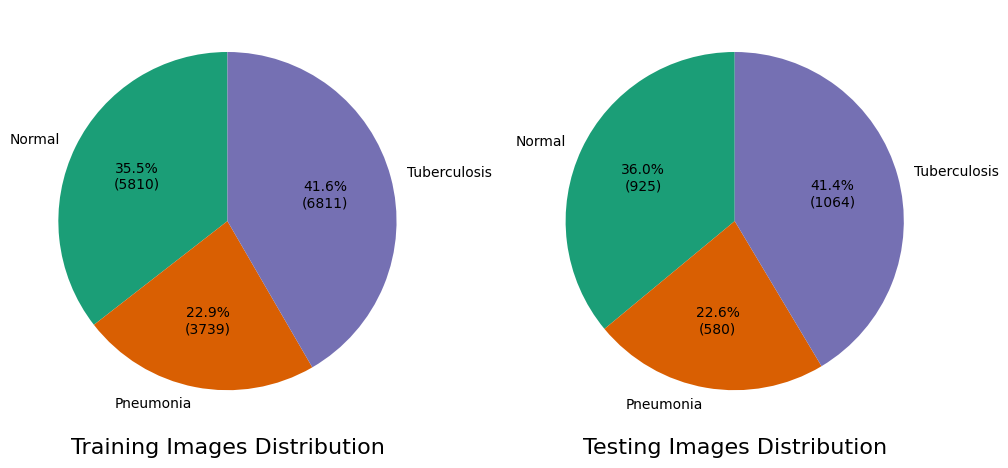

In [44]:
disease_labels = ["Normal", "Pneumonia", "Tuberculosis"]
test_image_counts = [ len(test_df[test_df['normal'] == 1]),  len(test_df[test_df['pneumonia'] == 1]),  len(test_df[test_df['tuberculosis'] == 1])]
train_image_counts = [ len(train_df[train_df['normal'] == 1]),  len(train_df[train_df['pneumonia'] == 1]),  len(train_df[train_df['tuberculosis'] == 1])]

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_format

cmap = cm.get_cmap('Dark2')
colors = cmap(np.linspace(0, 0.3, len(disease_labels)))
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].pie(train_image_counts, labels=disease_labels,
          autopct=autopct_format(train_image_counts), startangle=90, colors=colors)
ax[0].set_xlabel('Training Images Distribution', fontsize=16)
ax[1].pie(test_image_counts, labels=disease_labels,
          autopct=autopct_format(test_image_counts), startangle=90, colors=colors )
ax[1].set_xlabel('Testing Images Distribution', fontsize=16)

We have a similar distribution of image categories in  training and testing data with both of them having a lower representation of pneumonia data.

In [45]:
def create_tf_ds(df, batch_size=32, img_size=(256, 256), shuffle=True, augment=False):
    class_columns = [col for col in df.columns if col not in ['image_path', 'label', 'original_height', 'original_width', 'height_ratio', 'width_ratio']]

    image_paths = df['image_path'].values
    labels = df[class_columns].values.astype(np.float32)
    scale_features = df[['height_ratio', 'width_ratio']].values.astype(np.float32)

    def load_and_preprocess_image(path, label, scale):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = img / 255.0
        return {'image': img, 'scale': scale}, label

    def augment_image(inputs, label):
          img = inputs['image']
          # Random horizontal flip
          img = tf.image.random_flip_left_right(img)
          # Random brightness
          img = tf.image.random_brightness(img, max_delta=0.1)
          # Random contrast
          img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
          img = tf.clip_by_value(img, 0.0, 1.0)
          return {'image': img, 'scale': inputs['scale']}, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels, scale_features))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


In [46]:
train_ds = create_tf_ds(train_df, batch_size=32, shuffle=True, augment=True)
val_ds = create_tf_ds(val_df, batch_size=32, shuffle=False, augment=False)
test_ds = create_tf_ds(test_df, batch_size=32,  shuffle=False, augment=False)

## **Model Architecture**
We are going to build a convultional neural network with skip connections to retain information. Since this is a caterogrical image recognition task we will use softmax for the activaiton function on the output. To start we will keep the convolutional filters relatively small and expand from there in later models.

In [47]:
# Functions to be used in the neural net

# Instance Normalization
class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super(InstanceNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            shape=(input_shape[-1],),
            initializer="ones",
            trainable=True,
            name="gamma"
        )
        self.beta = self.add_weight(
            shape=(input_shape[-1],),
            initializer="zeros",
            trainable=True,
            name="beta"
        )
        super(InstanceNormalization, self).build(input_shape)

    def call(self, x):
        mean, var = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x_norm = (x - mean) / tf.sqrt(var + self.epsilon)
        return self.gamma * x_norm + self.beta




# Downsampling for convolutions
def downsample(filters, size, apply_instancenorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    gamma_init = keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

    result = keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

    if apply_instancenorm:
        result.add(InstanceNormalization())

    result.add(layers.LeakyReLU())

    return result

#Defining a learning rate for use in models
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=0.001, decay_steps=1000,decay_rate=0.96,staircase=True)

Building the model

In [48]:
def CNN(num_classes=3, dropout_rate=0.5):
    inp = layers.Input(shape=[256, 256, 3], name='image')
    scale_input = layers.Input(shape=[2], name='scale')

    # Encoder
    x = inp
    down1 = downsample(32, 4, False)(x)
    down2 = downsample(64, 4)(down1)
    down3 = downsample(128, 4)(down2)
    down4 = downsample(266, 4)(down3)

    # Multi-scale features
    conv_info_1 = layers.GlobalAveragePooling2D()(down1)
    conv_info_2 = layers.GlobalAveragePooling2D()(down2)
    conv_info_3 = layers.GlobalAveragePooling2D()(down3)
    conv_info_4 = layers.GlobalAveragePooling2D()(down4)

    # Scale processing
    scale_features = layers.Dense(32, activation='relu')(scale_input)
    scale_features = layers.BatchNormalization()(scale_features)
    scale_features = layers.Dense(16, activation='relu')(scale_features)


    x = layers.Dense(512, activation='relu')(conv_info_4)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(
        inputs={'image': inp, 'scale': scale_input},
        outputs=output,
        name='CNN_Simplified'
    )



In [49]:
model = CNN()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds
)

Model: "CNN_Simplified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_28       │ (None, 128, 128,  │      1,536 │ image[0][0]       │
│ (Sequential)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_29       │ (None, 64, 64,    │     32,896 │ sequential_28[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_30       │ (None, 32, 32,    │    131,328 │ sequential_29[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_31       │ (None, 16, 16,    │    545,300 │ sequential_30[0]… │
│ (Sequential)        │ 266)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 266)       │          0 │ sequential_31[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 512)       │    136,704 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_32[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 128)       │     65,664 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_33[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale (InputLayer)  │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 3)         │        387 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 916,375 (3.50 MB)

 Trainable params: 915,095 (3.49 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 68s 119ms/step - accuracy: 0.6102 - loss: 0.9140 - val_accuracy: 0.4161 - val_loss: 3.7402
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7027 - loss: 0.6078 - val_accuracy: 0.4166 - val_loss: 4.1403
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7182 - loss: 0.5572 - val_accuracy: 0.5183 - val_loss: 1.2607
Epoch 4/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7355 - loss: 0.5270 - val_accuracy: 0.4161 - val_loss: 7.9923
Epoch 5/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7357 - loss: 0.5124 - val_accuracy: 0.4161 - val_loss: 13.4590
Epoch 6/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7356 - loss: 0.5113 - val_accuracy: 0.3731 - val_loss: 1.7291
Epoch 7/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 106ms/step - accuracy: 0.7456 - loss: 0.4989 - val_accuracy: 0.4174 - val_loss: 5.7533
Epoch 8/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7375 - loss: 

This model appears to be struggling with validation accuracy. In the next model we will increase model complexity via adding more filters - this likely won't fix the problem as this model seems to be overfitting the training data as training loss is decreasing while validation loss is erratic.

In [50]:
def CNN_increased(num_classes=3, dropout_rate=0.5):
    inp = layers.Input(shape=[256, 256, 3], name='image')
    scale_input = layers.Input(shape=[2], name='scale')

    # Encoder
    x = inp
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)
    down4 = downsample(512, 4)(down3)

    # Multi-scale features
    conv_info_1 = layers.GlobalAveragePooling2D()(down1)
    conv_info_2 = layers.GlobalAveragePooling2D()(down2)
    conv_info_3 = layers.GlobalAveragePooling2D()(down3)
    conv_info_4 = layers.GlobalAveragePooling2D()(down4)

    # Scale processing
    scale_features = layers.Dense(32, activation='relu')(scale_input)
    scale_features = layers.BatchNormalization()(scale_features)
    scale_features = layers.Dense(16, activation='relu')(scale_features)


    x = layers.Dense(512, activation='relu')(conv_info_4)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(
        inputs={'image': inp, 'scale': scale_input},
        outputs=output,
        name='CNN_Simplified'
    )

In [51]:
model_inc = CNN_increased()

model_inc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_inc.summary()

history_inc = model_inc.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds
)

Model: "CNN_Simplified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_32       │ (None, 128, 128,  │      3,072 │ image[0][0]       │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_33       │ (None, 64, 64,    │    131,328 │ sequential_32[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_34       │ (None, 32, 32,    │    524,800 │ sequential_33[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_35       │ (None, 16, 16,    │  2,098,176 │ sequential_34[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ sequential_35[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 512)       │    262,656 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_37[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 128)       │     65,664 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_38[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale (InputLayer)  │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 3)         │        387 │ dropout_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,088,643 (11.78 MB)

 Trainable params: 3,087,363 (11.78 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 67s 116ms/step - accuracy: 0.6087 - loss: 0.9048 - val_accuracy: 0.5178 - val_loss: 2.2590
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7005 - loss: 0.5950 - val_accuracy: 0.4161 - val_loss: 6.4753
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7188 - loss: 0.5564 - val_accuracy: 0.4161 - val_loss: 12.1390
Epoch 4/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7331 - loss: 0.5252 - val_accuracy: 0.5758 - val_loss: 0.8889
Epoch 5/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7313 - loss: 0.5289 - val_accuracy: 0.5609 - val_loss: 1.4862
Epoch 6/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7270 - loss: 0.5260 - val_accuracy: 0.7443 - val_loss: 0.6556
Epoch 7/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7371 - loss: 0.5100 - val_accuracy: 0.4161 - val_loss: 2.5918
Epoch 8/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7435 - loss: 

Increasing model complexity through more filters is not getting us real gains in accuracy. Just as in the last model validation loss is unstable meaning the model is overfitting on the training data. Likely we are losing too much information via each convolution. Let's add skip connections to try and retain information from each layer in this next model.

In [52]:
def CNN_connected(num_classes=3, dropout_rate=0.5):
    inp = layers.Input(shape=[256, 256, 3], name='image')
    scale_input = layers.Input(shape=[2], name='scale')

    # Encoder
    x = inp
    down1 = downsample(64, 4, False)(x)
    down2 = downsample(128, 4)(down1)
    down3 = downsample(256, 4)(down2)
    down4 = downsample(512, 4)(down3)

    # Multi-scale features
    conv_info_1 = layers.GlobalAveragePooling2D()(down1)
    conv_info_2 = layers.GlobalAveragePooling2D()(down2)
    conv_info_3 = layers.GlobalAveragePooling2D()(down3)
    conv_info_4 = layers.GlobalAveragePooling2D()(down4)

    # Scale processing
    scale_features = layers.Dense(32, activation='relu')(scale_input)
    scale_features = layers.BatchNormalization()(scale_features)
    scale_features = layers.Dense(16, activation='relu')(scale_features)
    scale_features = layers.BatchNormalization()(scale_features)

    # Combine and classify
    combined = layers.Concatenate()([
        conv_info_1, conv_info_2, conv_info_3, conv_info_4, scale_features
    ])

    x = layers.Dense(512, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(
        inputs={'image': inp, 'scale': scale_input},
        outputs=output,
        name='CNN_Simplified'
    )

In [53]:
model_skip = CNN_connected()

model_skip.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_skip.summary()

history_skip= model_skip.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds
)

Model: "CNN_Simplified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_36       │ (None, 128, 128,  │      3,072 │ image[0][0]       │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale (InputLayer)  │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_37       │ (None, 64, 64,    │    131,328 │ sequential_36[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 32)        │         96 │ scale[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_38       │ (None, 32, 32,    │    524,800 │ sequential_37[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_40[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_39       │ (None, 16, 16,    │  2,098,176 │ sequential_38[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ sequential_36[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ sequential_37[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ sequential_38[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ sequential_39[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_41[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 976)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 512)       │    500,224 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_42[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 3,327,027 (12.69 MB)

 Trainable params: 3,325,651 (12.69 MB)

 Non-trainable params: 1,376 (5.38 KB)

Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 68s 117ms/step - accuracy: 0.7502 - loss: 0.5900 - val_accuracy: 0.6650 - val_loss: 0.9253
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 104ms/step - accuracy: 0.7669 - loss: 0.4517 - val_accuracy: 0.6814 - val_loss: 1.1649
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7727 - loss: 0.4152 - val_accuracy: 0.7782 - val_loss: 0.4257
Epoch 4/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7695 - loss: 0.4146 - val_accuracy: 0.7768 - val_loss: 0.5591
Epoch 5/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7687 - loss: 0.3955 - val_accuracy: 0.7711 - val_loss: 0.4037
Epoch 6/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7709 - loss: 0.3884 - val_accuracy: 0.7707 - val_loss: 0.3806
Epoch 7/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7681 - loss: 0.3758 - val_accuracy: 0.7399 - val_loss: 0.4703
Epoch 8/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7755 - loss: 0

Here we see an improvement in validation loss although there are some stability issues. Let's increase the depth of the model and see if we get better results.

In [54]:
def CNN_connected_deep(num_classes=3, dropout_rate=0.5):
    inp = layers.Input(shape=[256, 256, 3], name='image')
    scale_input = layers.Input(shape=[2], name='scale')

    # Encoder
    x = inp
    down1 = downsample(16, 4, False)(x)
    down2 = downsample(32, 4)(down1)
    down3 = downsample(64, 4)(down2)
    down4 = downsample(128, 4)(down3)
    down5 = downsample(256, 4)(down4)
    down6 = downsample(256, 4)(down5)
    down7 = downsample(512, 4)(down6)
    down8 = downsample(512, 4)(down7)

    # Multi-scale features
    conv_info_1 = layers.GlobalAveragePooling2D()(down1)
    conv_info_2 = layers.GlobalAveragePooling2D()(down3)
    conv_info_3 = layers.GlobalAveragePooling2D()(down5)
    conv_info_4 = layers.GlobalAveragePooling2D()(down7)

    # Scale processing
    scale_features = layers.Dense(32, activation='relu')(scale_input)
    scale_features = layers.BatchNormalization()(scale_features)
    scale_features = layers.Dense(16, activation='relu')(scale_features)
    scale_features = layers.BatchNormalization()(scale_features)

    # Combine and classify
    combined = layers.Concatenate()([
        conv_info_1, conv_info_2, conv_info_3, conv_info_4, scale_features
    ])

    x = layers.Dense(512, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(
        inputs={'image': inp, 'scale': scale_input},
        outputs=output,
        name='CNN_Simplified'
    )

In [55]:
model_skip_deep = CNN_connected_deep()

model_skip_deep.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_skip_deep.summary()

history_skip_deep= model_skip_deep.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds
)

Model: "CNN_Simplified"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_40       │ (None, 128, 128,  │        768 │ image[0][0]       │
│ (Sequential)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_41       │ (None, 64, 64,    │      8,256 │ sequential_40[0]… │
│ (Sequential)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_42       │ (None, 32, 32,    │     32,896 │ sequential_41[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_43       │ (None, 16, 16,    │    131,328 │ sequential_42[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale (InputLayer)  │ (None, 2)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_44       │ (None, 8, 8, 256) │    524,800 │ sequential_43[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 32)        │         96 │ scale[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_45       │ (None, 4, 4, 256) │  1,049,088 │ sequential_44[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_45[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_46       │ (None, 2, 2, 512) │  2,098,176 │ sequential_45[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 16)        │        528 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ sequential_40[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ sequential_42[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ sequential_44[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ sequential_46[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_46[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 864)       │          0 │ global_average_p

 Total params: 4,357,619 (16.62 MB)

 Trainable params: 4,356,243 (16.62 MB)

 Non-trainable params: 1,376 (5.38 KB)

Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 72s 120ms/step - accuracy: 0.7214 - loss: 0.6728 - val_accuracy: 0.7469 - val_loss: 0.4310
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7665 - loss: 0.4793 - val_accuracy: 0.7504 - val_loss: 0.4146
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7685 - loss: 0.4328 - val_accuracy: 0.7802 - val_loss: 0.4280
Epoch 4/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7749 - loss: 0.4152 - val_accuracy: 0.7800 - val_loss: 0.3592
Epoch 5/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7701 - loss: 0.3994 - val_accuracy: 0.7592 - val_loss: 0.3592
Epoch 6/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7716 - loss: 0.3944 - val_accuracy: 0.7790 - val_loss: 0.3606
Epoch 7/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - accuracy: 0.7727 - loss: 0.3912 - val_accuracy: 0.7809 - val_loss: 0.3520
Epoch 8/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 54s 105ms/step - accuracy: 0.7719 - loss: 0

/tmp/ipython-input-2528516779.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20b')(np.linspace(0, 1, 4))  # one color per model


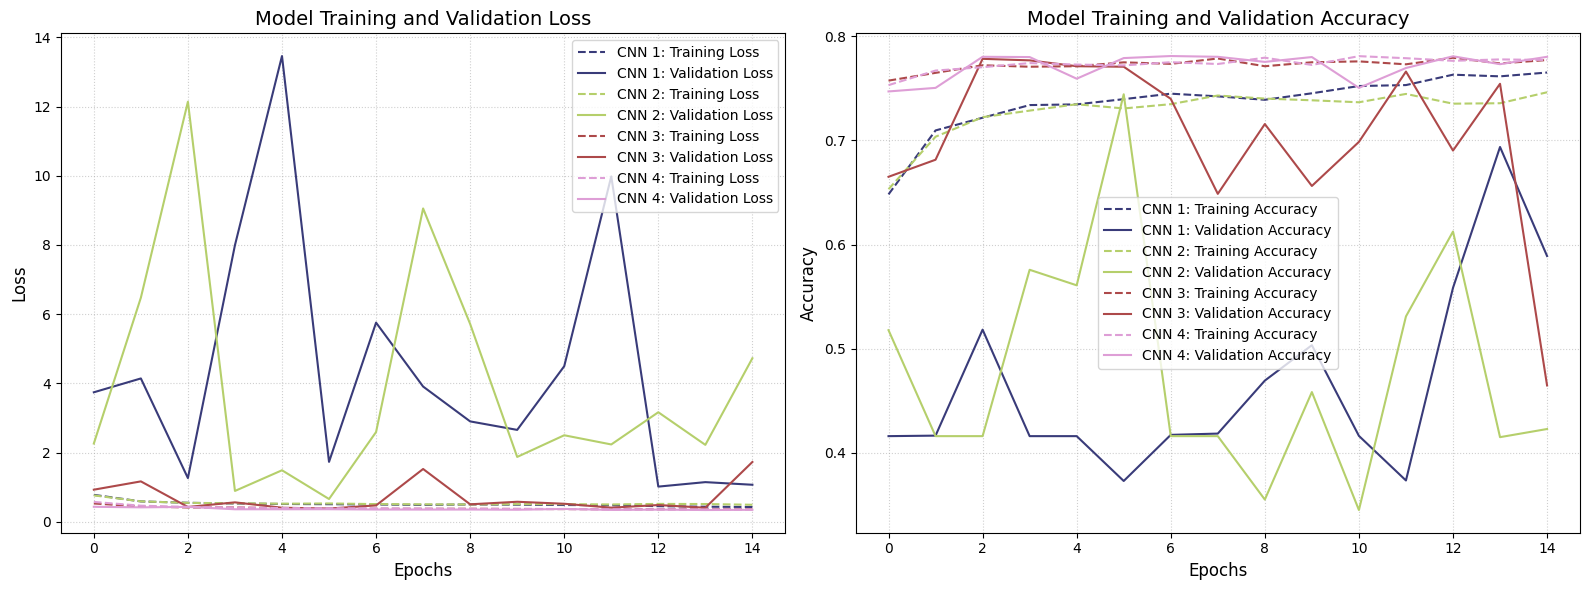

In [56]:
import matplotlib.cm as cm

colors = cm.get_cmap('tab20b')(np.linspace(0, 1, 4))  # one color per model

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ---- LOSS ----
ax[0].plot(history.history['loss'], '--', color=colors[0], label='CNN 1: Training Loss')
ax[0].plot(history.history['val_loss'], color=colors[0], label='CNN 1: Validation Loss')

ax[0].plot(history_inc.history['loss'], '--', color=colors[1], label='CNN 2: Training Loss')
ax[0].plot(history_inc.history['val_loss'], color=colors[1], label='CNN 2: Validation Loss')

ax[0].plot(history_skip.history['loss'], '--', color=colors[2], label='CNN 3: Training Loss')
ax[0].plot(history_skip.history['val_loss'], color=colors[2], label='CNN 3: Validation Loss')

ax[0].plot(history_skip_deep.history['loss'], '--', color=colors[3], label='CNN 4: Training Loss')
ax[0].plot(history_skip_deep.history['val_loss'], color=colors[3], label='CNN 4: Validation Loss')

ax[0].set_xlabel('Epochs', fontsize=12)
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_title('Model Training and Validation Loss', fontsize=14)
ax[0].legend(fontsize=10)
ax[0].grid(True, linestyle=':', alpha=0.6)

# ---- ACCURACY ----
ax[1].plot(history.history['accuracy'], '--', color=colors[0], label='CNN 1: Training Accuracy')
ax[1].plot(history.history['val_accuracy'], color=colors[0], label='CNN 1: Validation Accuracy')

ax[1].plot(history_inc.history['accuracy'], '--', color=colors[1], label='CNN 2: Training Accuracy')
ax[1].plot(history_inc.history['val_accuracy'], color=colors[1], label='CNN 2: Validation Accuracy')

ax[1].plot(history_skip.history['accuracy'], '--', color=colors[2], label='CNN 3: Training Accuracy')
ax[1].plot(history_skip.history['val_accuracy'], color=colors[2], label='CNN 3: Validation Accuracy')

ax[1].plot(history_skip_deep.history['accuracy'], '--', color=colors[3], label='CNN 4: Training Accuracy')
ax[1].plot(history_skip_deep.history['val_accuracy'], color=colors[3], label='CNN 4: Validation Accuracy')

ax[1].set_xlabel('Epochs', fontsize=12)
ax[1].set_ylabel('Accuracy', fontsize=12)
ax[1].set_title('Model Training and Validation Accuracy', fontsize=14)
ax[1].legend(fontsize=10)
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## **Results**
Plotting all four of the models' loss and accuracy vs epoch gives us a better look at the performance issues of the first three models. In the plot above CNN 1 corresponds to our first model, CNN 2 the second, CNN 3 is the model with skip connections, and CNN 4 is the deeper skip connections model.

In the first two models we see a high volatility in the validation loss / accuracy. This suggest overfitting on the training data which is likely happening because the models lack enough complexity to properly learn model parameters. Adding skip connections and depth greatly improves the validation performance as seen in CNN 3 & 4. None of the models are acheiving a great accuracy score. This could be do to many things including a relatively shallow NN design compared to modern CNN's. Additionally there might not be enough image data to properly train the model. As a final evaluation let's plot a confusion matrix of the best performing model (CNN 4).

In [58]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_probs = model_skip_deep.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

81/81 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step


In [59]:
class_columns = [col for col in test_df.columns if col not in ['image_path', 'label', 'original_height', 'original_width', 'height_ratio', 'width_ratio']]
class_names = sorted(class_columns)
accuracy = accuracy_score(y_true, y_pred)

Getting predictions on test set...

Total test samples: 2569
Class names: ['normal', 'pneumonia', 'tuberculosis']

Overall Test Accuracy: 0.7672 (76.72%)


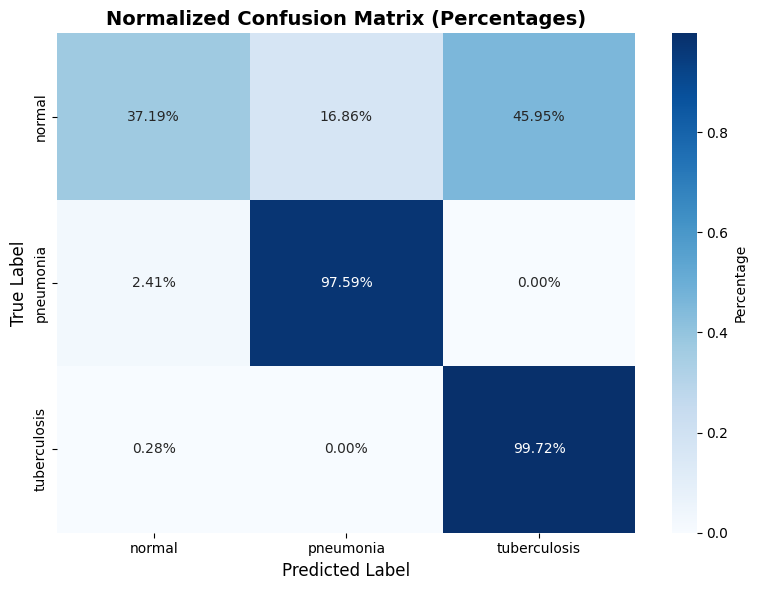

In [63]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions on test set
print("Getting predictions on test set...")
# y_pred_probs = model_improved.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

# Get class names
class_columns = [col for col in test_df.columns if col not in ['image_path', 'label', 'original_height', 'original_width', 'height_ratio', 'width_ratio']]
class_names = sorted(class_columns)

print(f"\nTotal test samples: {len(y_true)}")
print(f"Class names: {class_names}")

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")



# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## **Discusion / Conclusion**

The best model had an overall accuracy of 76% on the testing data. This is largely due to it's tendency to predict normal x-ray reading as either TB or pneumonia cases. Model accuracy on correctly diagnosing TB is over 97% and for pneumonia over 99%. The model only correctly diagnoses a normal case 37% of the time.

Future models will need improvement in diagnosing normal cases if it is to have any medical uses as the majority of pateints will be TB and pneumonia negative. The high accuracy rate of correctly identify the disease cases is promising as currently the model will not miss many diseased patients.

In order to improve future models a better CNN architecture should be used. Existing models such as ResNet or VGGNet with deeper architecture would likely perform better. Additionally, getting more data to train on would likely improve the model predictions.